In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
DRIMC — real-application cross-validation script (LOCAL).

Outer CV : 5 trials × 10-fold pairwise CV  (R's doCrossValidationByPairwise)
Inner CV : 3 × 80/20 ShuffleSplit at natural ratio (HP tuning)
Metrics  : AUPR, AUC, F1, Accuracy, Recall, Specificity, Precision

DRIMC pipeline:
  1. Load U, V, Y from staged_dataset.gz  (same as other methods)
  2. Jaccard similarity from U and V
  3. constrNeig → simD, simT              (constrained similarity, computed once)
  4. updateUV per fold/HP combo            (fit latent factors)
  5. Predict via simD @ est_U @ (simT @ est_V).T → sigmoid
"""

import os
import sys
import gzip
import pickle
import warnings
import logging

import numpy as np

from tqdm import TqdmSynchronisationWarning

warnings.simplefilter("ignore", TqdmSynchronisationWarning)

# single-threaded per HPC process — rpy2/R manages its own threading
# os.environ.setdefault("OMP_NUM_THREADS", "1")
# os.environ.setdefault("MKL_NUM_THREADS", "1")

In [2]:
# ====== user paths ======
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
DRIMC_PATH = os.path.join(PATH_ROOT, "scripts/methods/DRIMC")

# --- dataset selection (override with env var DATASET) ---
DATASET = os.environ.get("DATASET", "cdataset")
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis", DATASET)
PATH_OUTPUT = os.path.join(
    PATH_ROOT, "outputs/results/realAnalysis", DATASET, "fold_cv/origin"
)
PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")

for p in (PATH_OUTPUT, PATH_ARCHIVE):
    os.makedirs(p, exist_ok=True)

filenames = {"output": "results_drimc"}

In [3]:
# ====== Python imports ======
sys.path.append(PATH_ROOT)

from sgimc.utils import load
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import ParameterGrid, ShuffleSplit
from scipy.special import expit

# ====== R setup via rpy2 ======
import rpy2.robjects as robjects

r = robjects.r

r(f'setwd("{DRIMC_PATH}")')

# attach R packages
for pkg in ["matrixcalc", "data.table", "Rcpp", "ROCR", "Bolstad2", "MESS"]:
    r(f"library({pkg})")

# source R helper files (only what's needed)
for r_file in [
    "doCrossValidationByPairwise.R",
    "constrNeig.R",
    "calcLogLik.R",
    "calcDeriv.R",
    "updateUV.R",
]:
    r(f'source("{r_file}")')

# source C++ extensions needed by updateUV
r("library(Rcpp)")
for cpp_file in ["log1pexp.cpp", "sigmoid.cpp"]:
    r(f'sourceCpp("{cpp_file}")')

# bind R functions to Python
doCrossValidationByPairwise_R = r["doCrossValidationByPairwise"]
updateUV_R = r["updateUV"]
constrNeig_R = r["constrNeig"]


# ====== scoring helper (matches simulation scripts) ======
def get_metrics(real_score, predict_score):
    sorted_predict_score = np.array(
        sorted(list(set(np.array(predict_score).flatten())))
    )
    sorted_predict_score_num = len(sorted_predict_score)
    thresholds = sorted_predict_score[
        np.int32(sorted_predict_score_num * np.arange(1, 1000) / 1000)
    ]
    thresholds = np.mat(thresholds)
    thresholds_num = thresholds.shape[1]

    predict_score_matrix = np.tile(predict_score, (thresholds_num, 1))
    negative_index = np.where(predict_score_matrix < thresholds.T)
    positive_index = np.where(predict_score_matrix >= thresholds.T)
    predict_score_matrix[negative_index] = 0
    predict_score_matrix[positive_index] = 1
    TP = predict_score_matrix.dot(real_score.T)
    FP = predict_score_matrix.sum(axis=1) - TP
    FN = real_score.sum() - TP
    TN = len(real_score.T) - TP - FP - FN

    fpr = FP / (FP + TN)
    tpr = TP / (TP + FN)
    ROC_dot_matrix = np.mat(sorted(np.column_stack((fpr, tpr)).tolist())).T
    ROC_dot_matrix.T[0] = [0, 0]
    ROC_dot_matrix = np.c_[ROC_dot_matrix, [1, 1]]
    x_ROC = ROC_dot_matrix[0].T
    y_ROC = ROC_dot_matrix[1].T
    auc = 0.5 * (x_ROC[1:] - x_ROC[:-1]).T * (y_ROC[:-1] + y_ROC[1:])

    recall_list = tpr
    precision_list = TP / (TP + FP)
    PR_dot_matrix = np.mat(
        sorted(np.column_stack((recall_list, precision_list)).tolist())
    ).T
    PR_dot_matrix.T[0] = [0, 1]
    PR_dot_matrix = np.c_[PR_dot_matrix, [1, 0]]
    x_PR = PR_dot_matrix[0].T
    y_PR = PR_dot_matrix[1].T
    aupr = 0.5 * (x_PR[1:] - x_PR[:-1]).T * (y_PR[:-1] + y_PR[1:])

    f1_score_list = 2 * TP / (len(real_score.T) + TP - TN)
    accuracy_list = (TP + TN) / len(real_score.T)
    specificity_list = TN / (TN + FP)

    max_index = np.argmax(f1_score_list)
    f1_score = f1_score_list[max_index]
    accuracy = accuracy_list[max_index]
    specificity = specificity_list[max_index]
    recall = recall_list[max_index]
    precision = precision_list[max_index]
    return [aupr[0, 0], auc[0, 0], f1_score, accuracy, recall, specificity, precision]


# ====== helpers ======
def to_r_matrix(arr):
    return r.matrix(
        robjects.FloatVector(arr.flatten()),
        byrow=True,
        nrow=arr.shape[0],
        ncol=arr.shape[1],
    )


def extract_fold(savedFolds, trial, fold):
    fold_data = savedFolds.rx2(trial + 1).rx2(fold + 1)
    Y_train = np.array(fold_data.rx2(7))
    test_label = np.array(fold_data.rx2(1)).flatten()
    test_row = np.array(fold_data.rx2(3)).flatten().astype(int) - 1
    test_col = np.array(fold_data.rx2(4)).flatten().astype(int) - 1
    known_drug_idx = np.array(fold_data.rx2(5)).flatten().astype(int)
    known_target_idx = np.array(fold_data.rx2(6)).flatten().astype(int)
    return Y_train, test_row, test_col, test_label, known_drug_idx, known_target_idx

R callback write-console: data.table 1.17.8 using 6 threads (see ?getDTthreads).    
R callback write-console: Latest news: r-datatable.com
  


In [4]:
# ====== load dataset ======
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")
logging.info("Loading dataset: %s", DATASET)

filename_input = os.path.join(PATH_DATA, "cv_data", "staged_dataset.gz")
U, V, Y = load(filename_input)

# densify
U = np.asarray(U.toarray() if hasattr(U, "toarray") else U, dtype=float)
V = np.asarray(V.toarray() if hasattr(V, "toarray") else V, dtype=float)

# adjacency matrix for R's CV function
Y_dense = Y.toarray() if hasattr(Y, "toarray") else np.asarray(Y)
Y_adj = (Y_dense > 0).astype(float)

# ====== build similarity matrices (Jaccard, computed once) ======
logging.info("Computing Jaccard similarity matrices ...")
simD = 1 - pairwise_distances(U, metric="jaccard")
simT = 1 - pairwise_distances(V, metric="jaccard")

# handle NaN from all-zero rows (Jaccard is undefined → set self-sim = 1, rest = 0)
simD = np.nan_to_num(simD, nan=0.0)
simT = np.nan_to_num(simT, nan=0.0)
np.fill_diagonal(simD, 1.0)
np.fill_diagonal(simT, 1.0)

logging.info("simD: %s,  simT: %s", simD.shape, simT.shape)

# apply neighbourhood constraint via constrNeig (K=3, same as simulation)
K_neig = 20
simD_Robj = to_r_matrix(simD)
simT_Robj = to_r_matrix(simT)

logging.info("Applying constrNeig (K=%d) ...", K_neig)
lap = constrNeig_R(simD_Robj, simT_Robj, K=K_neig)
simD_R = lap.rx2("simD")
simT_R = lap.rx2("simT")
simD_np = np.array(simD_R)
simT_np = np.array(simT_R)
logging.info("Constrained simD: %s,  simT: %s", simD_np.shape, simT_np.shape)

# ====== create outer CV folds via R ======
kfold = 10
numSplit = 5
seeds_R = robjects.IntVector([7771, 8367, 22, 1812, 4659])

logging.info(
    "Creating %d trials × %d-fold pairwise CV splits via R ...", numSplit, kfold
)
savedFolds = doCrossValidationByPairwise_R(
    to_r_matrix(Y_adj), kfold=kfold, numSplit=numSplit, seeds=seeds_R
)

2026-05-11 17:28:57,922 INFO: Loading dataset: cdataset
2026-05-11 17:28:57,932 INFO: Computing Jaccard similarity matrices ...
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2182: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2182: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
2026-05-11 17:28:58,274 INFO: simD: (658, 658),  simT: (409, 409)
2026-05-11 17:28:58,277 INFO: Applying constrNeig (K=20) ...
2026-05-11 17:28:58,366 INFO: Constrained simD: (658, 658),  simT: (409, 409)
2026-05-11 17:28:58,366 INFO: Creating 5 trials × 10-fold pairwise CV splits via R ...


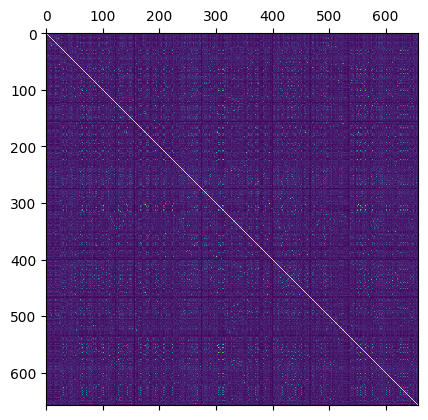

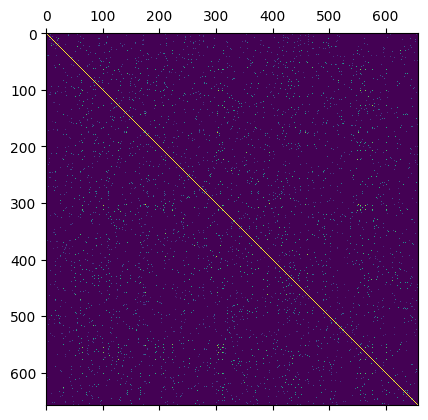

In [6]:
import matplotlib.pyplot as plt
plt.matshow(simD)
plt.matshow(simD_np)

In [7]:
# ====== parameter grid ======
grid_model = ParameterGrid(
    {
        "lamU": [1, 2, 4],
        "lamV": [2],
        "cc": [1, 5, 10],
        "iterpara": [0.125],
        "numLat": [50, 200],
    }
)

N_INNER_KFOLD = 10  # inner CV folds — 10-fold matches outer density (~90% 1's in train)
N_INNER_EVAL = 3  # only evaluate first 3 of N_INNER_KFOLD folds to save time

# ====== flatten combinations ======
combos = []
for trial in range(numSplit):
    for fold in range(kfold):
        for i_m, par_mdl in enumerate(grid_model):
            combos.append((trial, fold, i_m, par_mdl))
n_combos = len(combos)

In [8]:
# ====== local (notebook) run — loops over ALL combos ======
BASE_SEED = int(os.environ.get("BASE_SEED", str(0x0BADCAFE)))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [local] %(levelname)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

logging.info("LOCAL mode — running all %d combos", n_combos)

task_results = []

# cache inner CV folds per outer (trial, fold) — shared across HP combos
_inner_folds_cache = {}

# optional tqdm progress bar
try:
    from tqdm.auto import tqdm

    _iter = tqdm(range(n_combos), desc="combos", total=n_combos)
except ImportError:
    _iter = range(n_combos)

# ====== run all combos ======
for combo_idx in _iter:
    trial, fold, i_m, par_mdl = combos[combo_idx]
    logging.info(
        "Running combo_idx=%d (trial=%d, fold=%d, lamU=%s, lamV=%s, cc=%s)",
        combo_idx,
        trial,
        fold,
        par_mdl["lamU"],
        par_mdl["lamV"],
        par_mdl["cc"],
    )

    model_seed = BASE_SEED + combo_idx

    try:
        # ====== extract fold data ======
        Y_train_dense, test_row, test_col, test_label, _, _ = extract_fold(
            savedFolds, trial, fold
        )

        Y_train_Robj = to_r_matrix(Y_train_dense)

        # extract model params
        lamU = par_mdl["lamU"]
        lamV = par_mdl["lamV"]
        cc = par_mdl["cc"]
        iterpara = par_mdl["iterpara"]
        numLat = par_mdl["numLat"]

        # ====== fit on full training → test scores ======
        out = updateUV_R(
            cc=cc,
            inMat=Y_train_Robj,
            Sd=simD_R,
            St=simT_R,
            lamU=lamU,
            lamV=lamV,
            numLat=numLat,
            initMethod="useSeed",
            thisSeed=model_seed % (2**31 - 1),
            iterpara=iterpara,
            maxIter=1000,
        )
        est_U = np.array(out.rx2("U"))
        est_V = np.array(out.rx2("V"))

        # predict: simD @ est_U @ (simT @ est_V).T → sigmoid
        SA = simD_np @ est_U
        STB = simT_np @ est_V
        prob_full = expit(SA @ STB.T)
        prob_test = prob_full[test_row, test_col]

        scores_test = get_metrics(
            np.asarray(test_label, dtype=float),
            np.asarray(prob_test, dtype=float),
        )
        d1_test = int(sum(abs(est_U).max(axis=1) > 0))
        d2_test = int(sum(abs(est_V).max(axis=1) > 0))

        # ====== inner CV — pairwise CV on outer training matrix ======
        # Cache inner folds per (trial, fold): same split for all HP combos
        inner_cache_key = (trial, fold)
        if inner_cache_key not in _inner_folds_cache:
            inner_seed = (BASE_SEED + trial * 100 + fold + 31415) % (2**31 - 1)
            logging.info(
                "Creating inner %d-fold CV (evaluating %d) for trial=%d, fold=%d (seed=%d)",
                N_INNER_KFOLD,
                N_INNER_EVAL,
                trial,
                fold,
                inner_seed,
            )
            inner_savedFolds = doCrossValidationByPairwise_R(
                to_r_matrix(Y_train_dense),
                kfold=N_INNER_KFOLD,
                numSplit=1,
                seeds=robjects.IntVector([inner_seed]),
            )
            _inner_folds_cache[inner_cache_key] = inner_savedFolds
        inner_savedFolds = _inner_folds_cache[inner_cache_key]

        for cv in range(N_INNER_EVAL):
            # extract inner fold: Y_inner has validation entries zeroed out
            Y_inner, val_row, val_col, val_label, _, _ = extract_fold(
                inner_savedFolds, 0, cv  # trial=0 since numSplit=1
            )

            Y_inner_Robj = to_r_matrix(Y_inner)

            out_cv = updateUV_R(
                cc=cc,
                inMat=Y_inner_Robj,
                Sd=simD_R,
                St=simT_R,
                lamU=lamU,
                lamV=lamV,
                numLat=numLat,
                initMethod="useSeed",
                thisSeed=model_seed % (2**31 - 1),
                iterpara=iterpara,
                maxIter=1000,
            )
            est_U_cv = np.array(out_cv.rx2("U"))
            est_V_cv = np.array(out_cv.rx2("V"))

            SA_cv = simD_np @ est_U_cv
            STB_cv = simT_np @ est_V_cv
            prob_full_cv = expit(SA_cv @ STB_cv.T)
            prob_valid = prob_full_cv[val_row, val_col]
            scores_valid = get_metrics(
                np.asarray(val_label, dtype=float),
                np.asarray(prob_valid, dtype=float),
            )
            d1_valid = int(sum(abs(est_U_cv).max(axis=1) > 0))
            d2_valid = int(sum(abs(est_V_cv).max(axis=1) > 0))

            task_results.append(
                {
                    "trial": trial,
                    "fold": fold,
                    "lamU": lamU,
                    "lamV": lamV,
                    "cc": cc,
                    "iterpara": iterpara,
                    "numLat": numLat,
                    "cv": int(cv),
                    "val_score": scores_valid,
                    "val_d1": d1_valid,
                    "val_d2": d2_valid,
                    "test_score": scores_test,
                    "test_d1": d1_test,
                    "test_d2": d2_test,
                }
            )

    except Exception as e:
        logging.exception("Error at combo_idx=%d: %s", combo_idx, str(e))

2026-05-11 17:32:23,028 INFO: LOCAL mode — running all 900 combos
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
combos:   0%|          | 0/900 [00:00<?, ?it/s]2026-05-11 17:32:23,042 INFO: Running combo_idx=0 (trial=0, fold=0, lamU=1, lamV=2, cc=1)
2026-05-11 17:32:30,059 INFO: Creating inner 10-fold CV (evaluating 3) for trial=0, fold=0 (seed=195970485)
combos:   2%|▏         | 18/900 [09:12<8:44:45, 35.70s/it]2026-05-11 17:41:35,382 INFO: Running combo_idx=18 (trial=0, fold=1, lamU=1, lamV=2, cc=1)
2026-05-11 17:41:43,950 INFO: Creating inner 10-fold CV (evaluating 3) for trial=0, fold=1 (seed=195970486)
combos:   4%|▍         | 36/900 [18:26<7:03:58, 29.44s/it]2026-05-11 17:50:49,983 INFO: Running combo_idx=36 (trial=0, fold=2, lamU=1, lamV=2, cc=1)


In [9]:
# ====== save results ======
outfile = os.path.join(PATH_OUTPUT, f"{filenames['output']}.gz")

# archive any existing file so we don't silently overwrite a previous run
if os.path.exists(outfile):
    import time as _time

    mdttm = _time.strftime("%Y%m%d_%H%M%S")
    archived = os.path.join(PATH_ARCHIVE, f"{mdttm}_{os.path.basename(outfile)}")
    os.rename(outfile, archived)
    logging.info("Archived existing output to %s", archived)

logging.info("Saving %d result rows to %s", len(task_results), outfile)
with gzip.open(outfile, "wb+", 4) as fout:
    pickle.dump(task_results, fout)

logging.info("Local run finished.")

2026-05-12 10:02:14,477 INFO: Archived existing output to /Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/fold_cv/origin/archived/20260512_100214_results_drimc.gz
2026-05-12 10:02:14,478 INFO: Saving 2700 result rows to /Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/cdataset/fold_cv/origin/results_drimc.gz
2026-05-12 10:02:14,532 INFO: Local run finished.
